In [230]:
# Import packages
import os
import pandas as pd
from newspaper import Article
import spacy
import re
from gensim.models import Phrases
from tqdm.auto import tqdm
import pdb
import tomotopy as tp
import spacy
import stanza
from langdetect import detect, LangDetectException

### **Read files**

In [231]:
# 1. Load your downloaded CSV file
# IMPORTANT: Change 'your_downloaded_file.csv' to the actual name of your file!
file_name = "../data/gdelt/April16th_w_ELECTION_PROPAGANDA.csv"
print(f"Loading data from {file_name}...\n")
df = pd.read_csv(file_name)

# CLEANING THE DATA: remove duplicate rows
rows_before = len(df)
print(f"Number of rows before removing duplicates: {rows_before}")

df.drop_duplicates(inplace=True)

rows_after = len(df)
print(f"Number of rows after removing duplicates: {rows_after}")


Loading data from ../data/gdelt/April16th_w_ELECTION_PROPAGANDA.csv...

Number of rows before removing duplicates: 2943
Number of rows after removing duplicates: 2281


In [232]:
df.head(5)

,Event_Date,Initiator,Initiator_Country,Target,Total_Mentions,Unique_Outlets,Total_Articles,Social_Media_Mentioned,All_Organizations_Found,Themes,News_URL
0,20240913,CHINA,CHN,UNITED STATES,44,1,44,NaN,"Sandy Hook Elementary School,4051;Justice Depa...","TAX_WORLDMAMMALS_HUMANS,1053;EPU_POLICY_WHITE_...",https://www.yahoo.com/news/forget-cats-eat-hum...
2,20241105,RUSSIA,RUS,PENNSYLVANIA,40,4,40,NaN,"Embassy Russian,1231;Microsoft,2668;Agency Sec...","TAX_FNCACT_ANALYSTS,2643;TAX_DISEASE_OBESE,800...",https://orainfo.net/agjencite-federale-thone-s...
3,20240221,RUSSIAN,RUS,MARYLAND,30,6,30,NaN,"Associated Press,6259;Judiciary Committee,5986...","ECON_STOCKMARKET,1334;ARMEDCONFLICT,4853;TAX_F...",https://news.yahoo.com/ex-fbi-informant-charge...
4,20240420,BEIJING,CHN,THE US,30,3,30,NaN,"Senate Democratic,2250;United States,896;Unite...","DEMOCRACY,1133;DEMOCRACY,2250;CONFISCATION,203...",https://www.hometownregister.com/news/national...
5,20241006,RUSSIA,RUS,WASHINGTON,24,3,24,NaN,"Infrastructure Security Agency,1188;National I...","TAX_ETHNICITY_IRANIAN,2609;TAX_ETHNICITY_IRANI...",https://www.kcci.com/article/russia-iran-rampi...


### **Webscrapping**

In [233]:
print("\n" + "=" * 50)
print(" Date extraction and context retrieval from news articles")
print("=" * 50)

# --- Controls ---
N = len(df)  # Set to a smaller number for testing, or keep as is to process all
random_state = 42
cache_file = "../gdelt/articles_with_texts.csv"
use_cached_df = False   # If True and file exists, load it instead of scraping
save_cache = True      # Save freshly scraped data for next runs

if use_cached_df and os.path.exists(cache_file):
    print(f"Loading cached dataframe from: {cache_file}")
    df_w_texts = pd.read_csv(cache_file)
    print(f"Loaded {len(df_w_texts)} rows from cache.")
else:
    print("No cache found (or caching disabled). Starting scraping...")

    available_urls = df['News_URL'].dropna().unique().tolist()
    sample_n = min(N, len(available_urls))
    urls = pd.Series(available_urls).sample(n=sample_n, random_state=random_state, replace = False).tolist()

    rows = []

    for url in tqdm(urls, desc="Scraping articles", unit="article"):
        try:
            article = Article(url)
            article.download()
            article.parse()
            text = article.text

            event_date = df.loc[df['News_URL'] == url, 'Event_Date'].iloc[0]
            rows.append({
                'Event_Date': event_date,
                'News_URL': url,
                'Full_Text': text
            })

        except Exception:
            # Keep running even if one URL fails
            continue

    df_w_texts = pd.DataFrame(rows, columns=['Event_Date', 'News_URL', 'Full_Text'])
    print(f"Scraped {len(df_w_texts)} articles successfully.")

    if save_cache:
        df_w_texts.to_csv(cache_file, index=False)
        print(f"Saved cache to: {cache_file}")


 Date extraction and context retrieval from news articles
No cache found (or caching disabled). Starting scraping...


Scraping articles:   0%|          | 0/1325 [00:00<?, ?article/s]

Scraping articles:   1%|          | 14/1325 [00:18<22:20,  1.02s/article] Building prefix dict from c:\Users\danie\anaconda3\envs\interference\Lib\site-packages\jieba\dict.txt ...
Loading model from cache C:\Users\danie\AppData\Local\Temp\jieba.cache
Loading model cost 0.9661328792572021 seconds.
Prefix dict has been built succesfully.
Scraping articles: 100%|██████████| 1325/1325 [28:21<00:00,  1.28s/article] 


Scraped 1129 articles successfully.
Saved cache to: ../gdelt/articles_with_texts.csv


In [234]:
df_w_texts["Full_Text"].iloc[0]

'The House yesterday [Macau time] passed a bill that would lead to a nationwide ban of the popular video app TikTok if its China-based owner doesn’t sell its stake, as lawmakers acted on concerns that the company’s current ownership structure is a national security threat.\n\nThe bill, passed by a vote of 352-65, now goes to the Senate, where its prospects are unclear.\n\nTikTok, which has more than 170 million American users, is a wholly-owned subsidiary of Chinese technology firm ByteDance Ltd.\n\nThe lawmakers contend that ByteDance “is beholden to the Chinese government,” which could demand access to the data of TikTok’s consumers in the U.S. whenever it wants. The worry stems from a set of Chinese national security laws that compel organizations to assist with intelligence gathering.\n\n“We have given TikTok a clear choice,” said Rep. Cathy McMorris Rodgers, R-Wash. “Separate from your parent company ByteDance, which is beholden to the CCP, and remain operational in the United Sta

In [235]:
def clean_scraped_text(text):
    # \s+ looks for ANY whitespace (\n, \t, \r, or multiple spaces) 
    # and replaces it with a single standard space ' '
    text = re.sub(r'-\s+', '', text)
    cleaned_text = re.sub(r'\s+', ' ', text)
    
    # .strip() removes any lingering spaces at the very beginning or end of the article
    return cleaned_text.strip()

In [236]:
df_w_texts.dropna(inplace=True)
df_w_texts.reset_index(drop=True, inplace=True)

for i in range(len(df_w_texts)):
    df_w_texts.loc[i, 'Full_Text'] = clean_scraped_text(df_w_texts.loc[i, 'Full_Text'])

df_w_texts.drop(df_w_texts[df_w_texts['Full_Text'] == ''].index, inplace=True)


In [237]:
df_w_texts["Full_Text"].iloc[1]

"As the US presidential election draws nearer, Iran has intensified its efforts to sway American public opinion, joining the ongoing influence campaigns by Russia and China. According to a new report from Microsoft's Threat Analysis Center, Iranian operatives are using fake news sites and cyber operations to target voters across the political spectrum. This move marks a significant escalation in Iran's attempts to influence the U.S. election, with researchers warning that these activities could increase as voting day approaches. Fake news sites target both political left and right Microsoft's report highlights several fake news sites attributed to Iranian operations, designed to appeal to both liberal and conservative audiences. One of these sites, Nio Thinker, positions itself as a progressive news outlet, publishing content critical of former President Donald Trump while praising Vice President Kamala Harris. Another site, Savannah Time, takes on a conservative voice, blending local 

In [238]:
df_w_texts.sample(5)

,Event_Date,News_URL,Full_Text
575,20240309,https://www.ncr-iran.org/en/news/global-recogn...,Facebook Twitter LinkedIn Pinterest Reddit Ema...
1000,20240122,https://eng.obozrevatel.com/section-war/news-t...,The leadership of the terrorist state of Russi...
859,20241009,https://www.pymnts.com/cybersecurity/2024/open...,OpenAI says hackers connected to the Chinese g...
372,20240109,https://www.breitbart.com:443/asia/2024/01/09/...,China’s state-run propaganda newspaper Global ...
25,20240322,https://www.globalissues.org/news/2024/03/22/3...,10:36 AM The meeting has adjourned and there i...


In [239]:
detect(" Міністр закордонних справ Росії Сергій")

'uk'

### **Data Cleaning**

In [240]:
custom_words_to_remove = [
    # 1. REPORTING VERBS (The mechanics of journalism)
    "say", "tell", "report", "state", "add", "continue", "note", "speak",
    "announce", "publish", "write", "claim", "ask", "answer", "respond",
    "explain", "describe", "mention", "declare", "comment", "discuss",
    
    # 2. JOURNALISM & PUBLISHING JARGON
    "news", "reporter", "correspondent", "press", "release", "statement", 
    "source", "interview", "article", "column", "editorial", "editor", 
    "broadcast", "medium", "newspaper", "magazine", "coverage", "story",
    "headline", "journalist", "author",
    
    # 3. WEB & UI ARTIFACTS (Scraping noise)
    "read", "subscribe", "newsletter", "advertisement", "click", "share", 
    "update", "image", "photo", "video", "audio", "link", "website", 
    "page", "home", "copyright", "follow", "loading", "sign", "register",
    "cookie", "term", "condition", "browser",
    "download", "menu", "search", "advertisement",
    
    # 4. TIME & DATE MARKERS (Usually irrelevant to the actual topic)
    "today", "yesterday", "tomorrow", "week", "month", "year", "time", 
    "day", "minute", "hour", "morning", "afternoon", "evening", "daily", 
    "weekly", "annual", "monday", "tuesday", "wednesday", "thursday", 
    "friday", "saturday", "sunday", "january", "february", "march", "april",
    "may", "june", "july", "august", "september", "october", "november", "december",
    
    # 5. TITLES, PRONOUNS, & GENERIC FILLER
    "mr", "mrs", "ms", "dr", "sir", "madam", "people", "person", "man", 
    "woman", "like", "know", "think", "look", "good", "new", "old", "way", 
    "thing", "come", "go", "take", "get", "make", "use", "want", "find",
    "need", "work", "give", "try", "leave", "call", "lot", "bit"
]

In [260]:
df_w_texts.value_counts(subset = ['Language'])

Language
en          925
Name: count, dtype: int64

In [241]:
remove_other_languages = True

if remove_other_languages:

    df_w_texts['Language'] = df_w_texts['Full_Text'].apply(lambda x: detect(x) if pd.notnull(x) else 'unknown')
    df_w_texts = df_w_texts[df_w_texts['Language'] == 'en'].reset_index(drop=True)

    #  Load the spaCy language model
    nlp = spacy.load("en_core_web_sm")

    #  Add your manual words to the Stop Word list
    for word in custom_words_to_remove:
        nlp.vocab[word].is_stop = True

    raw_texts = df_w_texts['Full_Text'].tolist()
    english_processed_docs = []

    # The Lemmatization & Stop Word Pipeline
    for doc in nlp.pipe(raw_texts):
        # This single line does the heavy lifting:
        # It extracts the lemma, converts to lowercase, and drops stop words/punctuation
        clean_tokens = [
            token.lemma_.lower() 
            for token in doc 
            if not token.is_stop and not token.is_punct and token.is_alpha
        ]
        english_processed_docs.append(clean_tokens)


else:

    # 1. SETUP BOTH LIBRARIES
    # Load spaCy for speed
    nlp_spacy = {
        'en': spacy.load("en_core_web_sm"),
        'ru': spacy.load("ru_core_news_sm"),
        'el': spacy.load("el_core_news_sm")
    }

    # Load Stanza for coverage (tokenize, lemma, and POS tagging are included)
    # We disable 'ner' (Named Entity Recognition) to make it run slightly faster
    nlp_stanza = {
        'ar': stanza.Pipeline('ar', processors='tokenize,mwt,pos,lemma', use_gpu=False),
        'tr': stanza.Pipeline('tr', processors='tokenize,pos,lemma', use_gpu=False)
    }

    def safe_detect(text):
        try:
            return detect(str(text))
        except LangDetectException:
            return "unknown"

    # 2. HYBRID PREPROCESSING LOOP
    print("Detecting languages and preprocessing...")
    native_tokenized_docs = [] 

    for idx, row in tqdm(df_w_texts.iterrows(), total=len(df_w_texts), desc="Cleaning Texts"):
        lang = safe_detect(row['Full_Text'])
        text = row['Full_Text']
        
        # Route 1: The Fast spaCy Path
        if lang in nlp_spacy:
            doc = nlp_spacy[lang](text)
            tokens = [
                token.lemma_.lower() 
                for token in doc 
                if not token.is_stop and not token.is_punct and token.is_alpha
            ]
            native_tokenized_docs.append((lang, tokens))
            
        # Route 2: The Accurate Stanza Fallback
        elif lang in nlp_stanza:
            doc = nlp_stanza[lang](text)
            tokens = []
            
            # Stanza structures data slightly differently (Doc -> Sentences -> Words)
            for sentence in doc.sentences:
                for word in sentence.words:
                    # Stanza doesn't have a built-in 'is_stop' flag like spaCy.
                    # But we can filter by Part of Speech (POS).
                    # We keep Nouns (NOUN), Verbs (VERB), and Adjectives (ADJ).
                    # This naturally strips out foreign stop words (pronouns, conjunctions, etc.)
                    if word.upos in ['NOUN', 'VERB', 'ADJ'] and word.lemma:
                        tokens.append(word.lemma.lower())
                        
            native_tokenized_docs.append((lang, tokens))
            
        # Route 3: True Unknowns (Junk data, or languages you completely ignore)
        else:
            native_tokenized_docs.append((lang, [])) 

    print("Preprocessing complete!")

In [243]:
# The N-Gramming Pipeline
# Train the Gensim Phrases model on your cleaned text
bigram_model = Phrases(english_processed_docs, min_count=7, threshold=0.005)

# Apply the trained n-gram model back to your documents
final_documents = [bigram_model[doc] for doc in english_processed_docs]

df_w_texts['Processed_Tokens'] = final_documents


In [244]:
df_w_texts.head()

,Event_Date,News_URL,Full_Text,Language,Processed_Tokens
0,20240315,https://macaudailytimes.com.mo/house-passes-bi...,The House yesterday [Macau time] passed a bill...,en,"[house, macau, pass_bill, lead, nationwide_ban..."
1,20240809,https://invezz.com/news/2024/08/09/iran-steps-...,"As the US presidential election draws nearer, ...",en,"[presidential_election, draw, nearer, iran, in..."
2,20240512,https://www.dailymail.co.uk/news/article-13409...,A softly-spoken former bank clerk has stepped ...,en,"[softly, speak, bank, clerk, step, shoe, vladi..."
3,20240210,https://www.cnn.com/2024/02/10/politics/russia...,A version of this story appeared in CNN’s What...,en,"[version, appear, cnn, matter, inbox, free, cn..."
4,20241025,https://www.wired.com/story/trump-vance-phones...,With the United States presidential election l...,en,"[united_states, presidential_election, week_aw..."


In [245]:
print("\nChunking large documents to improve topic modeling...")

def chunk_dataframe(df, token_col='Processed_Tokens', text_col='Full_Text', chunk_size=1000):
    """
    Slices long documents into smaller chunks while preserving the original text 
    and a reference to the original row index.
    """
    chunked_rows = []
    
    # Use tqdm to show a progress bar
    for original_idx, row in tqdm(df.iterrows(), total=len(df), desc="Chunking"):
        doc_tokens = row[token_col]
        original_text = row[text_col]
        
        # 1. Skip completely empty documents (Fixes the tomotopy empty doc bug!)
        if not isinstance(doc_tokens, list) or len(doc_tokens) == 0:
            continue
            
        # 2. If the document is shorter than the chunk size, keep it as one piece
        if len(doc_tokens) <= chunk_size:
            chunked_rows.append({
                'Original_Index': original_idx,
                'Chunk_ID': 1, # Just 1 chunk
                'Unified_Tokens': doc_tokens,
                'Full_Text': original_text
            })
            
        # 3. Slicing long documents
        else:
            chunk_counter = 1
            for i in range(0, len(doc_tokens), chunk_size):
                chunk = doc_tokens[i : i + chunk_size]
                
                # Only keep chunks that have enough words to be meaningful
                if len(chunk) > 20: 
                    chunked_rows.append({
                        'Original_Index': original_idx,
                        'Chunk_ID': chunk_counter,
                        'Unified_Tokens': chunk,
                        'Full_Text': original_text
                    })
                    chunk_counter += 1
                    
    # Return a brand new dataframe containing the split chunks
    return pd.DataFrame(chunked_rows)

# Apply the function to your existing dataframe
df_chunked = chunk_dataframe(df_w_texts, chunk_size=600)

print(f"\nOriginal document count: {len(df_w_texts)}")
print(f"New chunked document count: {len(df_chunked)}")


Chunking large documents to improve topic modeling...


Chunking: 100%|██████████| 925/925 [00:00<00:00, 11676.27it/s]


Original document count: 925
New chunked document count: 1344


In [246]:
df_chunked.head()

,Original_Index,Chunk_ID,Unified_Tokens,Full_Text
0,0,1,"[house, macau, pass_bill, lead, nationwide_ban...",The House yesterday [Macau time] passed a bill...
1,1,1,"[presidential_election, draw, nearer, iran, in...","As the US presidential election draws nearer, ..."
2,2,1,"[softly, speak, bank, clerk, step, shoe, vladi...",A softly-spoken former bank clerk has stepped ...
3,2,2,"[assassination, order, vladimir_putin, threate...",A softly-spoken former bank clerk has stepped ...
4,3,1,"[version, appear, cnn, matter, inbox, free, cn...",A version of this story appeared in CNN’s What...


In [247]:
final_chunked_documents = df_chunked['Unified_Tokens'].tolist()

### Topic Modeling

#### Seed generation

In [262]:
seed_lexicon = {
    "propaganda": ["propaganda", "disinformation", "misinformation", "fake_news", "influence_operation",],
    "election_interference": ["election_interference", "foreign_interference", 'interference'],
    "hacking": ["hack", "hacking", "cyber_attack", "cyberattack", "hacker", "fake_site"],
    "russian-influence": ["russian_influence", "russian_propaganda", "russian_disinformation", "russian_actor"]
}

In [263]:
# Count seed lexicon
seed_counts = {topic: 0 for topic in seed_lexicon}
for topic, keywords in seed_lexicon.items():
    for keyword in keywords:
        for doc in final_chunked_documents:
            if keyword in doc:
                seed_counts[topic] += 1
print("Seed Lexicon Counts:")
for topic, count in seed_counts.items():
    print(f"{topic}: {count}") 

Seed Lexicon Counts:
propaganda: 813
election_interference: 182
hacking: 187
russian-influence: 224


#### Model estimation

In [271]:
iterations=20000
seed_weight=1.0
regular_weight=0.001

    
# 1. Initialize the Model with all tuning parameters
# We use TermWeight.IDF to penalize common words and boost specific, topical words
mdl = tp.LDAModel(
    k=50, 
    alpha=0.2, 
    eta=0.001, 
    min_cf=5, 
    rm_top=100, 
    tw=tp.TermWeight.IDF 
)

documents_for_model = final_chunked_documents 

# 2. Add Documents
print(f"Adding {len(documents_for_model)} documents to the model...")
for doc in documents_for_model:
    mdl.add_doc(doc)
    
# 3. Create Topic Mappings
# Map 'Economy' -> 0, 'Politics' -> 1, etc.
topic_name_to_id = {name: i for i, name in enumerate(seed_lexicon.keys())}
topic_id_to_name = {i: name for name, i in topic_name_to_id.items()}

# 4. Inject the Asymmetric Priors (The Seeds)
print("Applying mathematical seeds...")
seeded_word_count = 0
missing_seed_words = []

for topic_name, words in seed_lexicon.items():
    topic_id = topic_name_to_id[topic_name]
    
    for word in words:
        
        try:
            priors = [regular_weight] * mdl.k
            priors[topic_id] = seed_weight
            
            # If the word isn't in the model, tomotopy throws a ValueError here
            mdl.set_word_prior(word, priors)
            seeded_word_count += 1
            
        except ValueError:
            # Catch the error safely and record the missing word
            missing_seed_words.append(word)
            
print(f"Successfully anchored {seeded_word_count} seed words.")

# 5. Train the Model (Gibbs Sampling)
print(f"Training for {iterations} iterations...")
mdl.train(0) # Initialize parameters

for i in range(0, iterations, 200):
    mdl.train(100)
    print(f"Iteration: {i + 100}\tLog-likelihood: {mdl.ll_per_word:.4f}")
    
print("Training complete!")


Adding 1344 documents to the model...
Applying mathematical seeds...
Successfully anchored 18 seed words.
Training for 100000 iterations...


c:\Users\danie\anaconda3\envs\interference\Lib\site-packages\tomotopy\models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


Iteration: 100	Log-likelihood: -9.1187
Iteration: 300	Log-likelihood: -9.0100
Iteration: 500	Log-likelihood: -8.9401
Iteration: 700	Log-likelihood: -8.8849
Iteration: 900	Log-likelihood: -8.8428
Iteration: 1100	Log-likelihood: -8.8094
Iteration: 1300	Log-likelihood: -8.7791
Iteration: 1500	Log-likelihood: -8.7531
Iteration: 1700	Log-likelihood: -8.7339
Iteration: 1900	Log-likelihood: -8.7152
Iteration: 2100	Log-likelihood: -8.6966
Iteration: 2300	Log-likelihood: -8.6810
Iteration: 2500	Log-likelihood: -8.6673
Iteration: 2700	Log-likelihood: -8.6577
Iteration: 2900	Log-likelihood: -8.6455
Iteration: 3100	Log-likelihood: -8.6335
Iteration: 3300	Log-likelihood: -8.6236
Iteration: 3500	Log-likelihood: -8.6149
Iteration: 3700	Log-likelihood: -8.6096
Iteration: 3900	Log-likelihood: -8.6006
Iteration: 4100	Log-likelihood: -8.5891
Iteration: 4300	Log-likelihood: -8.5827
Iteration: 4500	Log-likelihood: -8.5755
Iteration: 4700	Log-likelihood: -8.5708
Iteration: 4900	Log-likelihood: -8.5653
Itera

In [273]:
# 1. Get the total number of words assigned to each topic
# This helps you see how "big" or "heavy" each topic is in your corpus
topic_counts = mdl.get_count_by_topics()

print("\n========== ALL TOPICS OVERVIEW ==========\n")

# Loop through every single topic from 0 up to K
for k_id in range(mdl.k):
    
    # 2. Determine the Label (Seeded vs. Unseeded)
    if k_id in topic_id_to_name:
        # It's one of your seeded topics
        topic_label = f"✅ SEEDED [{topic_id_to_name[k_id]}]"
    else:
        # It's an unseeded noise topic
        topic_label = f"⬜ UNSEEDED (Topic {k_id})"
        
    # 3. Get the Top 10 Words
    top_words = [word for word, prob in mdl.get_topic_words(k_id, top_n=10)]
    
    # 4. Print the results clearly, including the word count
    print(f"{topic_label} | Size: {topic_counts[k_id]} words")
    print(f"   Keywords: {', '.join(top_words)}\n")


========== ALL TOPICS OVERVIEW ==========

✅ SEEDED [propaganda] | Size: 3435 words
   Keywords: censorship, jankowicz, alethea, disinformation, twitter, google, censor, gec, misinformation, clinton

✅ SEEDED [election_interference] | Size: 4320 words
   Keywords: meta, researcher, account, facebook, ai, content, user, deng, x, platform

✅ SEEDED [hacking] | Size: 17655 words
   Keywords: hack, official_say, disinformation, intelligence_official, cyber, influence_operation, actor, online, adversary, voter

✅ SEEDED [russian-influence] | Size: 7141 words
   Keywords: hunter_biden, smirnov, fbi, investigation, comer, burisma, laptop, dnc, cia, clinton

⬜ UNSEEDED (Topic 4) | Size: 2862 words
   Keywords: story_continue, canada, brainwashing, chinese_government, ad, rfa, privacy, canadians, app, tiktok_influence

⬜ UNSEEDED (Topic 5) | Size: 2705 words
   Keywords: eu, cso, drew_holden, moldova, psaki, kallas, european_union, european, defence, slovakia

⬜ UNSEEDED (Topic 6) | Size: 3921

#### Check topic distribution of documents

In [274]:
# 1. Select the document you want to inspect (e.g., Document index 42)
doc_index = 0
target_doc = list(mdl.docs)[doc_index]

# 2. Get the mathematical distribution
# This returns a list of probabilities (one for each of your K topics) that sum to 1.0
topic_dist = target_doc.get_topic_dist()

print(f"--- Topic Distribution for Document #{doc_index} ---")

# Optional: Print the original text so you can see if the math makes sense!
# (Assuming your dataframe index matches the tomotopy document index)
print(f"Original Text snippet: {df_w_texts['Full_Text'].iloc[doc_index][:200]}...\n")

# 3. Loop through the distribution and print the results clearly
for topic_id, probability in enumerate(topic_dist):
    
    # We only want to print topics that actually have a meaningful presence in the document.
    # Let's ignore any topic that makes up less than 5% of the article.
    if probability > 0.05: 
        
        # Look up the human-readable name if it's a seeded topic
        topic_name = topic_id_to_name.get(topic_id, f"Unseeded Topic {topic_id}")
        
        # Convert the decimal probability to a clean percentage
        percentage = probability * 100
        
        # Print the Topic Name and its Percentage
        print(f"{topic_name}: {percentage:.1f}%")
        
        # Print the top 5 words of that topic so you know what it represents
        top_words = [word for word, prob in mdl.get_topic_words(topic_id, top_n=5)]
        print(f"   Keywords: {', '.join(top_words)}\n")

--- Topic Distribution for Document #0 ---
Original Text snippet: The House yesterday [Macau time] passed a bill that would lead to a nationwide ban of the popular video app TikTok if its China-based owner doesn’t sell its stake, as lawmakers acted on concerns that ...

Unseeded Topic 17: 9.6%
   Keywords: interest, result, member, security, provide

Unseeded Topic 34: 79.1%
   Keywords: app, bill, ban, bytedance, vpn



#### Check corpus topic distribution

In [275]:
# 1. Get the raw word counts for every topic
topic_counts = mdl.get_count_by_topics()

# 2. Calculate the total number of valid words the model processed
total_words = sum(topic_counts)

print(f"Total words modeled: {total_words:,}")
print("\n========== CORPUS TOPIC DISTRIBUTION ==========\n")

# 3. Calculate percentages and store them so we can sort them
corpus_distribution = []

for k_id in range(mdl.k):
    # Calculate the exact percentage of the corpus this topic occupies
    percentage = (topic_counts[k_id] / total_words) * 100 if total_words > 0 else 0
    
    # Apply the correct human-readable label
    if k_id in topic_id_to_name: 
        label = f"✅ SEEDED [{topic_id_to_name[k_id]}]"
    else:
        label = f"⬜ UNSEEDED (Topic {k_id})"
        
    # Append a tuple: (Percentage, Label, Raw Word Count, Topic ID)
    corpus_distribution.append((percentage, label, topic_counts[k_id], k_id))

# 4. Sort the list from the largest topic to the smallest topic
corpus_distribution.sort(reverse=True, key=lambda x: x[0])

# 5. Print the formatted results WITH Top Words
for percentage, label, count, k_id in corpus_distribution:
    # We only print topics that actually have words assigned to them
    if count > 0:
        # Extract the top 5 words for this specific topic
        top_words = [word for word, prob in mdl.get_topic_words(k_id, top_n=5)]
        
        # Print the stats and the keywords nicely formatted
        print(f"{label:<30} | {percentage:>5.2f}%  ({count:,} words)")
        print(f"   Keywords: {', '.join(top_words)}\n")

Total words modeled: 427,989

========== CORPUS TOPIC DISTRIBUTION ==========

⬜ UNSEEDED (Topic 17)          | 21.45%  (91,810 words)
   Keywords: interest, result, member, security, provide

⬜ UNSEEDED (Topic 42)          | 16.38%  (70,117 words)
   Keywords: want, big, talk, run, happen

⬜ UNSEEDED (Topic 23)          |  7.80%  (33,393 words)
   Keywords: fight, fail, hope, history, regime

⬜ UNSEEDED (Topic 16)          |  4.60%  (19,688 words)
   Keywords: economic, nuclear, economy, strategic, conflict

✅ SEEDED [hacking]             |  4.13%  (17,655 words)
   Keywords: hack, official_say, disinformation, intelligence_official, cyber

⬜ UNSEEDED (Topic 24)          |  4.00%  (17,129 words)
   Keywords: arrest, child, police, protest, prison

⬜ UNSEEDED (Topic 39)          |  3.07%  (13,144 words)
   Keywords: kyiv, zelensky, ukrainians, crimea, europe

⬜ UNSEEDED (Topic 41)          |  2.52%  (10,792 words)
   Keywords: harris, raddatz, lie, advertisement, democrats

⬜ UNSEEDED 

### Time distribution of topics

In [276]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Extracting topic distributions...


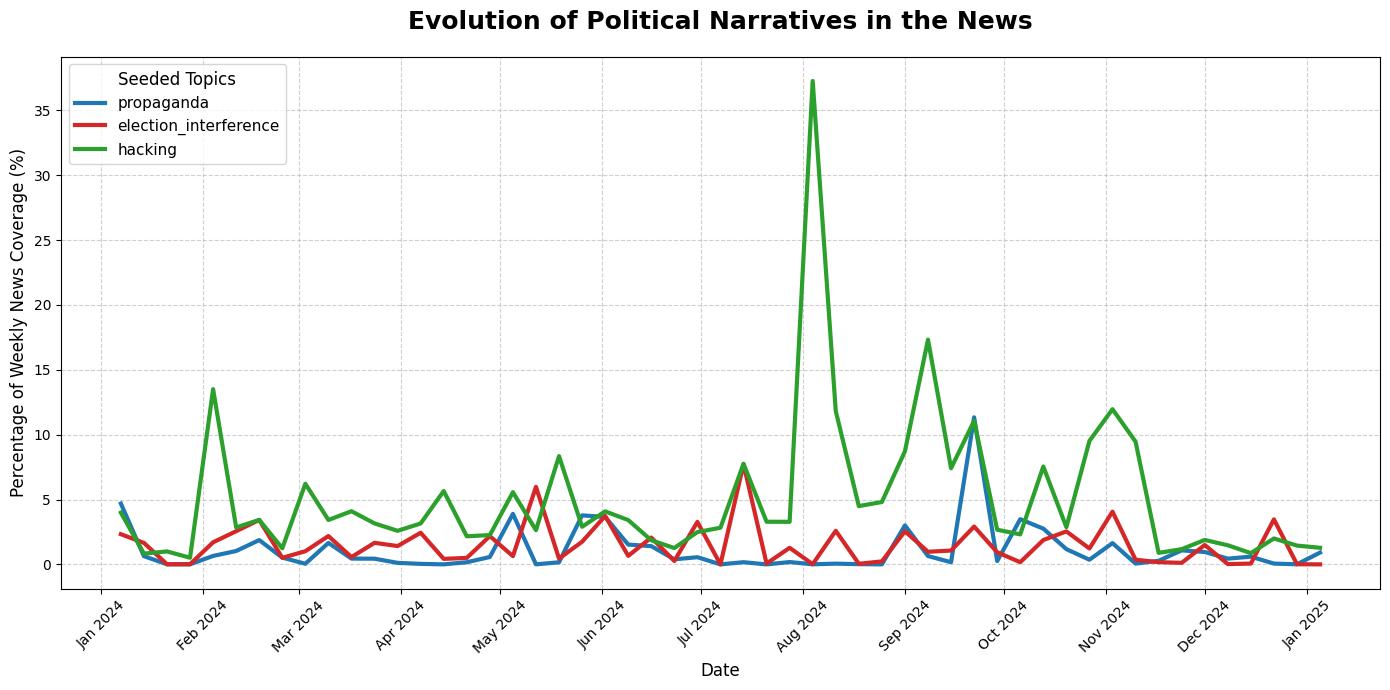

In [277]:


# ==========================================
# 1. EXTRACT DATA & REASSEMBLE THE CHUNKS
# ==========================================
print("Extracting topic distributions...")

# Create a list to hold the data for every chunk
chunk_data = []

# Loop through every document in the tomotopy model
for idx, doc in enumerate(mdl.docs):
    # Get the mathematical distribution across all topics for this specific chunk
    dist = doc.get_topic_dist()
    
    # Get the original article index from our chunked dataframe
    original_idx = df_chunked.iloc[idx]['Original_Index']
    
    # Store it as a dictionary
    row_data = {'Original_Index': original_idx}
    for k_id, prob in enumerate(dist):
        row_data[f'Topic_{k_id}'] = prob
        
    chunk_data.append(row_data)

# Convert to a DataFrame
df_dists = pd.DataFrame(chunk_data)

# Because one article was split into multiple chunks, we group by the Original_Index
# and take the mean to reconstruct the article's total topic distribution.
df_article_topics = df_dists.groupby('Original_Index').mean().reset_index()

# ==========================================
# 2. MERGE WITH THE ORIGINAL TIMESTAMPS
# ==========================================
# Merge the topic distributions back into your original dataframe using the index
# (Assuming your original dataframe has a column named 'Published_Date')
df_final = df_w_texts[['Event_Date']].merge(
    df_article_topics, 
    left_index=True, 
    right_on='Original_Index'
)

# Ensure the date column is officially recognized by pandas as a Datetime object
df_final['Published_Date'] = pd.to_datetime(
    df_final['Event_Date'].astype(str), 
    format='%Y%m%d'
)

# ==========================================
# 3. AGGREGATE BY WEEK & SMOOTH
# ==========================================
# Set the date as the index so we can do time-series math
df_final.set_index('Published_Date', inplace=True)

# Group the data by Week ('W') and calculate the mean topic probability for that week
weekly_trends = df_final.resample('W').mean()

# Apply a 3-week rolling average to smooth out the jagged spikes
# min_periods=1 ensures the graph doesn't drop the first two weeks
smoothed_trends = weekly_trends.rolling(window=1, min_periods=1).mean()

# ==========================================
# 4. PLOTTING THE EVOLUTION
# ==========================================
# Set up a large, clean figure
plt.figure(figsize=(14, 7))

# Choose which specific topics you want to plot so it isn't too cluttered
# Let's assume you want to plot your seeded topics (e.g., IDs 0, 1, and 2)
# You can look up your exact IDs from your `topic_id_to_name` mapping
topics_to_plot = [0, 1, 2] 

# Define some nice colors
colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']

for i, k_id in enumerate(topics_to_plot):
    # Get the human-readable label
    label = topic_id_to_name.get(k_id, f"Topic {k_id}")
    
    # Plot the smoothed line
    # Multiply by 100 to convert decimals to percentages (e.g., 0.25 -> 25%)
    plt.plot(
        smoothed_trends.index, 
        smoothed_trends[f'Topic_{k_id}'] * 100, 
        label=label, 
        linewidth=3,
        color=colors[i % len(colors)]
    )

# Format the Graph visually
plt.title("Evolution of Political Narratives in the News", fontsize=18, fontweight='bold', pad=20)
plt.ylabel("Percentage of Weekly News Coverage (%)", fontsize=12)
plt.xlabel("Date", fontsize=12)

# Format the X-axis dates nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1)) # Show a tick every 1 month
plt.xticks(rotation=45)

# Add a grid, legend, and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Seeded Topics", fontsize=11, title_fontsize=12, loc='upper left')
plt.tight_layout()

# Save or display the plot
plt.savefig("topic_evolution.png", dpi=300)
plt.show()

### BERTopic Modelling ???